<center>

# [Компьютерное зрение](http://rairi.ru/wiki/index.php/%D0%9A%D0%BE%D0%BC%D0%BF%D1%8C%D1%8E%D1%82%D0%B5%D1%80%D0%BD%D0%BE%D0%B5_%D0%B7%D1%80%D0%B5%D0%BD%D0%B8%D0%B5)

## <center> Семинар 11 - Трекинг

<a target="_blank" href="https://colab.research.google.com/github/alexmelekhin/cv_course_2023/blob/main/seminars/seminar_11/Seminar_11.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

***

In [5]:
# Install manually if needed:
# !pip install ultralytics scipy opencv-python matplotlib
# Optional external ByteTrack demo dependencies:
# !pip install filterpy lap

In [6]:
from typing import Tuple
from time import time
import types
import os
from pathlib import Path

(Path.cwd() / ".ultralytics").mkdir(exist_ok=True)
os.environ.setdefault("YOLO_CONFIG_DIR", str(Path.cwd() / ".ultralytics"))

from scipy.optimize import linear_sum_assignment
import numpy as np
import cv2
import matplotlib.pyplot as plt

from ultralytics import YOLO

# Вспомогательные функции

In [7]:
def show_image(img: np.ndarray) -> None:
    plt.figure(figsize=(10,5))
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
    plt.show()


def detection_visualization(
    img_path: Path, preds: np.ndarray
) -> np.ndarray:
    img = cv2.imread(str(img_path)) # Read image with cv2
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB
    for i in range(len(preds)):
        cv2.rectangle(
            img,
            (int(preds[i][0]), int(preds[i][1])),
            (int(preds[i][2]), int(preds[i][3])),
            color=(0, 255, 0),
            thickness=3,
        )
    return img


def tracking_visualization(
    img_path: Path, preds: np.ndarray
) -> np.ndarray:
    img = cv2.imread(str(img_path)) # Read image with cv2
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB
    for i in range(len(preds)):
        cv2.rectangle(
            img,
            (int(preds[i][0]), int(preds[i][1])),
            (int(preds[i][2]), int(preds[i][3])),
            color=(0, 255, 0),
            thickness=3,
        )
        cv2.putText(
            img,
            str(int(preds[i][4])),
            (int(preds[i][0]), int(preds[i][1])),
            cv2.FONT_HERSHEY_SIMPLEX,
            fontScale=2,
            color=(0, 255, 0),
            thickness=3
        )
    return img


# Датасет

В рамках данного семинара мы будем использовать трек `MOT17-09` из датасета MOT Challenge https://motchallenge.net/

Ссылка на скачивание датасета https://motchallenge.net/data/MOT17Det/ 

In [8]:
# Set this manually if the automatic search does not find your MOT17-09 frames.
# Example: MOT17_09_DIR = r"C:\datasets\MOT17Det\train\MOT17-09\img1"
MOT17_09_DIR = r"C:\tmp\mot17_downloads\extracted\MOT17-50\train\MOT17-09\img1"


def find_mot17_09_frames() -> list:
    """Find MOT17-09 image frames locally or in common MOT layouts."""
    candidates = []
    if MOT17_09_DIR is not None:
        candidates.append(Path(MOT17_09_DIR))
    candidates.extend([
        Path("/home/melekhin_aa/Datasets/MOT17_09_imgs"),
        Path.home() / "Datasets/MOT17_09_imgs",
        Path.home() / "Datasets/MOT17Det/train/MOT17-09/img1",
        Path.home() / "Downloads/MOT17Det/train/MOT17-09/img1",
        Path("MOT17_09_imgs"),
        Path("MOT17-09/img1"),
        Path("MOT17/train/MOT17-09/img1"),
        Path("MOT17Det/train/MOT17-09/img1"),
        Path("data/MOT17/train/MOT17-09/img1"),
        Path("data/MOT17Det/train/MOT17-09/img1"),
    ])
    
    def _frames_from_dir(path: Path) -> list:
        if not path.exists() or not path.is_dir():
            return []
        return sorted(
            p for p in path.iterdir()
            if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
        )
    
    for candidate in candidates:
        frames = _frames_from_dir(candidate)
        if frames:
            return frames
    
    for candidate in Path.cwd().rglob("img1"):
        if "mot17-09" not in str(candidate).lower():
            continue
        frames = _frames_from_dir(candidate)
        if frames:
            return frames
    
    raise FileNotFoundError(
        "MOT17-09 frames were not found. Download MOT17Det from https://motchallenge.net/data/MOT17Det/ "
        "and set MOT17_09_DIR to the img1 folder, e.g. r'C:\\datasets\\MOT17Det\\train\\MOT17-09\\img1'."
    )


frames_list = find_mot17_09_frames()
dataset_dir = frames_list[0].parent
print(f"Using dataset_dir={dataset_dir}")
print(f"Found {len(frames_list)} frames")

Using dataset_dir=C:\tmp\mot17_downloads\extracted\MOT17-50\train\MOT17-09\img1
Found 262 frames


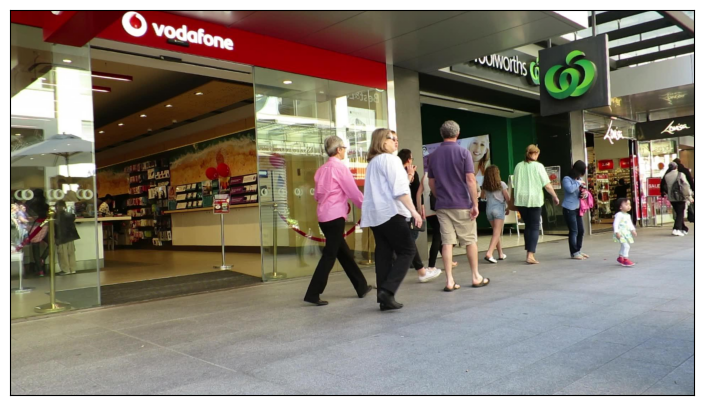

In [9]:
img = cv2.cvtColor(cv2.imread(str(frames_list[0])), cv2.COLOR_BGR2RGB)
show_image(img)

# Детекция с помощью YOLOv8

В качестве бэкбона детекции мы будем использовать YOLOv8s из библиотеки ultralytics: https://github.com/ultralytics/ultralytics

In [10]:
def find_yolo_weights(weights_name: str = "yolov8s.pt") -> str:
    """Use local weights if present; otherwise let Ultralytics download them."""
    direct_candidate = Path(weights_name)
    if direct_candidate.exists():
        return str(direct_candidate)
    
    matches = sorted(Path.cwd().rglob(weights_name))
    if matches:
        return str(matches[0])
    
    return weights_name


class YoloDetector:
    def __init__(self, conf_threshold: float = 0.5, weights_name: str = "yolov8s.pt") -> None:
        weights_path = find_yolo_weights(weights_name)
        print(f"Loading YOLO weights from: {weights_path}")
        self.backbone = YOLO(weights_path)
        self.conf_threshold = conf_threshold
    
    def __call__(self, img_path: Path) -> np.ndarray:
        preds = self.backbone.predict(source=img_path, conf=self.conf_threshold, show=False, classes=0)
        preds = preds[0].boxes.data.cpu().numpy()[:, :5]
        return preds

Loading YOLO weights from: yolov8s.pt

image 1/1 C:\tmp\mot17_downloads\extracted\MOT17-50\train\MOT17-09\img1\000001.jpg: 384x640 9 persons, 89.0ms
Speed: 4.9ms preprocess, 89.0ms inference, 78.9ms postprocess per image at shape (1, 3, 384, 640)


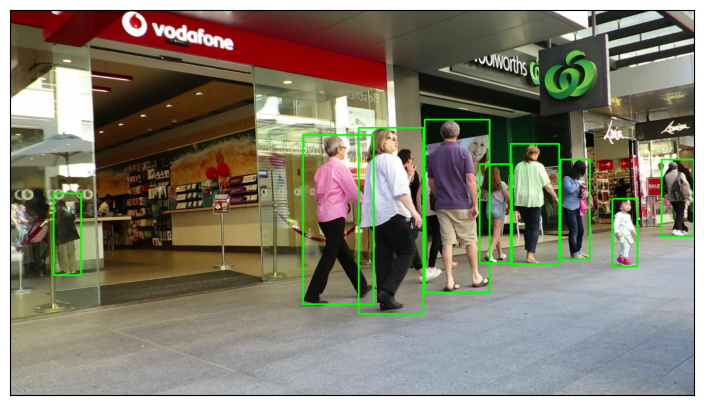

In [11]:
detector = YoloDetector()
preds = detector(frames_list[0])

out_frame = detection_visualization(frames_list[0], preds)
show_image(out_frame)

# Алгоритм трекинга SORT

SORT: https://arxiv.org/abs/1602.00763

Разделы "3.3. Data Association" и "3.4. Creation and Deletion of Track Identities" описывают алгоритм соотнесения результатов детекции последовательных кадров:

> **3.3. Data Association**
> 
> In assigning detections to existing targets, each target’s
> bounding box geometry is estimated by predicting its new
> location in the current frame. The assignment cost matrix is
> then computed as the intersection-over-union (IOU) distance
> between each detection and all predicted bounding boxes
> from the existing targets. The assignment is solved optimally
> using the Hungarian algorithm. Additionally, a minimum
> IOU is imposed to reject assignments where the detection to
> target overlap is less than $IOU_{min}$.
>
> We found that the IOU distance of the bounding boxes
> implicitly handles short term occlusion caused by passing targets.
> Specifically, when a target is covered by an occluding
> object, only the occluder is detected, since the IOU distance
> appropriately favours detections with similar scale. This allows
> both the occluder target to be corrected with the detection while 
> the covered target is unaffected as no assignment is made.

> **3.4. Creation and Deletion of Track Identities**
>
> When objects enter and leave the image, unique identities
> need to be created or destroyed accordingly. For creating
> trackers, we consider any detection with an overlap less than
> $IOU_{min}$ to signify the existence of an untracked object. The
> tracker is initialised using the geometry of the bounding box
> with the velocity set to zero. Since the velocity is unobserved
> at this point the covariance of the velocity component is initialised
> with large values, reflecting this uncertainty. Additionally, the new
> tracker then undergoes a probationary period where the target needs
> to be associated with detections to accumulate enough evidence in order
> to prevent tracking of false positives.
> 
> Tracks are terminated if they are not detected for $T_{Lost}$
> frames. This prevents an unbounded growth in the number
> of trackers and localisation errors caused by predictions over
> long durations without corrections from the detector. In all
> experiments $T_{Lost}$ is set to 1 for two reasons. Firstly, the constant
> velocity model is a poor predictor of the true dynamics
> and secondly we are primarily concerned with frame-to-frame
> tracking where object re-identification is beyond the scope of
> this work. Additionally, early deletion of lost targets aids efficiency.
> Should an object reappear, tracking will implicitly resume under a new identity.

# Венгерский алгоритм (Hungarian algorithm)

- [Wikipedia](https://en.wikipedia.org/wiki/Hungarian_algorithm)
- Реализация в библиотеке scipy: [`scipy.optimize.linear_sum_assignment`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linear_sum_assignment.html)
- Реализация в библиотеке [lap](https://github.com/gatagat/lap): `lap.lapjv` 

## Задание 1:

Реализуйте Венгерский алгоритм. Сравните возвращаемые значения с библиотечной функцией [`scipy.optimize.linear_sum_assignment`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linear_sum_assignment.html).

In [12]:
def hungarian_algorithm(cost_matrix: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Solves the assignment problem using the Hungarian algorithm.

    Args:
        cost_matrix (np.ndarray): Numpy array of shape (n, m) representing the cost matrix.

    Returns:
        A tuple of two numpy arrays (row_ind, col_ind) representing the row and column indices
        of the assigned cells in the cost matrix.
    """
    cost = np.asarray(cost_matrix, dtype=float)
    if cost.ndim != 2:
        raise ValueError("cost_matrix must be a 2D array")
    
    n_rows, n_cols = cost.shape
    if n_rows == 0 or n_cols == 0:
        return np.array([], dtype=int), np.array([], dtype=int)
    
    def _solve_rectangular(a: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        # The implementation below follows the standard O(n^3) shortest augmenting path
        # version of the Hungarian algorithm for the case n_rows <= n_cols.
        n, m = a.shape
        u = np.zeros(n + 1)
        v = np.zeros(m + 1)
        p = np.zeros(m + 1, dtype=int)
        way = np.zeros(m + 1, dtype=int)
        
        for i in range(1, n + 1):
            p[0] = i
            j0 = 0
            minv = np.full(m + 1, np.inf)
            used = np.zeros(m + 1, dtype=bool)
            
            while True:
                used[j0] = True
                i0 = p[j0]
                delta = np.inf
                j1 = 0
                
                for j in range(1, m + 1):
                    if used[j]:
                        continue
                    cur = a[i0 - 1, j - 1] - u[i0] - v[j]
                    if cur < minv[j]:
                        minv[j] = cur
                        way[j] = j0
                    if minv[j] < delta:
                        delta = minv[j]
                        j1 = j
                
                for j in range(m + 1):
                    if used[j]:
                        u[p[j]] += delta
                        v[j] -= delta
                    else:
                        minv[j] -= delta
                
                j0 = j1
                if p[j0] == 0:
                    break
            
            while True:
                j1 = way[j0]
                p[j0] = p[j1]
                j0 = j1
                if j0 == 0:
                    break
        
        row_ind = []
        col_ind = []
        for j in range(1, m + 1):
            if p[j] != 0:
                row_ind.append(p[j] - 1)
                col_ind.append(j - 1)
        return np.array(row_ind, dtype=int), np.array(col_ind, dtype=int)
    
    if n_rows <= n_cols:
        row_ind, col_ind = _solve_rectangular(cost)
    else:
        transposed_rows, transposed_cols = _solve_rectangular(cost.T)
        row_ind = transposed_cols
        col_ind = transposed_rows
    
    order = np.argsort(row_ind)
    return row_ind[order], col_ind[order]


In [13]:
cost_matrix = np.array([[1, 2, 3],
                        [4, 5, 6],
                        [7, 8, 9]])
my_row_ind, my_col_ind = hungarian_algorithm(cost_matrix)
my_cost = cost_matrix[my_row_ind, my_col_ind].sum()
row_ind, col_ind = linear_sum_assignment(cost_matrix)
cost = cost_matrix[row_ind, col_ind].sum()

assert my_cost == cost


test_matrices = [
    np.array([[4, 1, 3], [2, 0, 5], [3, 2, 2]]),
    np.array([[10, 19, 8, 15], [10, 18, 7, 17], [13, 16, 9, 14]]),
    np.array([[7, 3], [3, 6], [9, 2], [8, 5]]),
    np.array([[0.5, -1.0, 2.0], [1.0, 0.0, -2.0]]),
]

for matrix in test_matrices:
    my_row_ind, my_col_ind = hungarian_algorithm(matrix)
    row_ind, col_ind = linear_sum_assignment(matrix)
    my_cost = matrix[my_row_ind, my_col_ind].sum()
    scipy_cost = matrix[row_ind, col_ind].sum()
    assert np.isclose(my_cost, scipy_cost), f"Expected {scipy_cost}, got {my_cost}"

print("Hungarian algorithm tests passed")

Hungarian algorithm tests passed


# Алгоритм трекинга ByteTrack

- Статья https://arxiv.org/abs/2110.06864
- Код https://github.com/ifzhang/ByteTrack


## Вопрос 1:

В чем заключается ключевая особенность метода BYTE?

**Ответ:**

Ключевая особенность BYTE состоит в том, что он не отбрасывает низкоуверенные детекции сразу. Сначала треки сопоставляются с high-score detections, а затем оставшиеся неподтвержденные треки дополнительно сопоставляются с low-score detections. Это помогает сохранить ID объекта при частичной окклюзии, motion blur или временном падении confidence.

In [14]:
# !git clone https://github.com/ifzhang/ByteTrack.git
# %cd ByteTrack
# !pip install -r requirements.txt
# !python setup.py develop
# %cd ..
# !pip install cython
# !pip install 'git+https://github.com/cocodataset/cocoapi.git#subdirectory=PythonAPI'
# !pip install cython_bbox

In [15]:
# Optional demo of the original ByteTrack implementation.
# It is skipped by default because the self-contained Re-ID tracker below does not need yolox.
RUN_EXTERNAL_BYTETRACK_DEMO = False

if RUN_EXTERNAL_BYTETRACK_DEMO:
    from yolox.tracker.byte_tracker import BYTETracker
    
    fps = 30
    first_frame = cv2.imread(str(frames_list[0]))
    frame_size = first_frame.shape[:2]
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    output_file = 'output.mp4'
    video_writer = cv2.VideoWriter(output_file, fourcc, fps, frame_size[::-1])
    
    args = types.SimpleNamespace(**{
        "track_thresh": 0.5,
        "track_buffer": 30,
        "match_thresh": 0.8,
        "mot20": False,
    })
    tracker = BYTETracker(args, frame_rate=fps)
    
    det_times = []
    track_times = []
    
    for frame_path in frames_list:
        s_time = time()
        detections = detector(frame_path)
        det_times.append((time() - s_time) * 1000)  # in ms
        s_time = time()
        tracks = tracker.update(detections, frame_size, frame_size)
        track_times.append((time() - s_time) * 1000)  # in ms
        tracks = [t.tlbr.tolist() + [t.track_id] for t in tracks]
        out_frame = tracking_visualization(frame_path, tracks)
        video_writer.write(cv2.cvtColor(out_frame, cv2.COLOR_RGB2BGR))
    video_writer.release()
    
    print(f"mean detection time: {np.mean(det_times)}, mean track time: {np.mean(track_times)}")
else:
    print("External yolox ByteTrack demo skipped. The final Re-ID tracker below is self-contained.")

External yolox ByteTrack demo skipped. The final Re-ID tracker below is self-contained.


## Задание 2

Объедините BYTE и любой трекер с Re-ID признаками (например, FairMOT). Можно воспользоваться инструкциями из репозитория: https://github.com/ifzhang/ByteTrack/tree/main/tutorials

Ответом на это задание должен быть код, записывающий видео работы метода для трека MOT17-09 в файл `reid_out.mp4`. Убедитесь, что код работает "end-to-end". 

In [16]:
def find_mot17_09_frames() -> list:
    """Find MOT17-09 frames in common local layouts."""
    candidates = []
    if "MOT17_09_DIR" in globals() and MOT17_09_DIR is not None:
        candidates.append(Path(MOT17_09_DIR))
    if "dataset_dir" in globals():
        candidates.append(Path(dataset_dir))
    candidates.extend([
        Path("/home/melekhin_aa/Datasets/MOT17_09_imgs"),
        Path.home() / "Datasets/MOT17_09_imgs",
        Path.home() / "Datasets/MOT17Det/train/MOT17-09/img1",
        Path.home() / "Downloads/MOT17Det/train/MOT17-09/img1",
        Path("MOT17_09_imgs"),
        Path("MOT17-09/img1"),
        Path("MOT17/train/MOT17-09/img1"),
        Path("MOT17Det/train/MOT17-09/img1"),
        Path("data/MOT17/train/MOT17-09/img1"),
        Path("data/MOT17Det/train/MOT17-09/img1"),
    ])
    
    for candidate in candidates:
        if candidate.exists() and candidate.is_dir():
            frames = sorted(
                p for p in candidate.iterdir()
                if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
            )
            if len(frames) > 0:
                return frames
    
    for candidate in Path.cwd().rglob("img1"):
        if "mot17-09" not in str(candidate).lower():
            continue
        frames = sorted(
            p for p in candidate.iterdir()
            if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
        )
        if len(frames) > 0:
            return frames
    
    raise FileNotFoundError(
        "MOT17-09 frames were not found. Download MOT17Det from https://motchallenge.net/data/MOT17Det/ "
        "and set MOT17_09_DIR to the img1 folder, e.g. r'C:\\datasets\\MOT17Det\\train\\MOT17-09\\img1'."
    )


def bbox_iou_matrix(boxes1: np.ndarray, boxes2: np.ndarray) -> np.ndarray:
    boxes1 = np.asarray(boxes1, dtype=float)
    boxes2 = np.asarray(boxes2, dtype=float)
    if len(boxes1) == 0 or len(boxes2) == 0:
        return np.zeros((len(boxes1), len(boxes2)), dtype=float)
    
    left_top = np.maximum(boxes1[:, None, :2], boxes2[None, :, :2])
    right_bottom = np.minimum(boxes1[:, None, 2:], boxes2[None, :, 2:])
    wh = np.clip(right_bottom - left_top, 0, None)
    intersection = wh[..., 0] * wh[..., 1]
    area1 = np.clip(boxes1[:, 2] - boxes1[:, 0], 0, None) * np.clip(boxes1[:, 3] - boxes1[:, 1], 0, None)
    area2 = np.clip(boxes2[:, 2] - boxes2[:, 0], 0, None) * np.clip(boxes2[:, 3] - boxes2[:, 1], 0, None)
    union = area1[:, None] + area2[None, :] - intersection
    return np.divide(intersection, union, out=np.zeros_like(intersection), where=union > 0)


def extract_reid_feature(frame_rgb: np.ndarray, bbox: np.ndarray) -> np.ndarray:
    """Simple Re-ID descriptor: normalized HSV color histogram of the detection crop."""
    h, w = frame_rgb.shape[:2]
    x1, y1, x2, y2 = np.round(bbox[:4]).astype(int)
    x1, x2 = np.clip([x1, x2], 0, w - 1)
    y1, y2 = np.clip([y1, y2], 0, h - 1)
    if x2 <= x1 or y2 <= y1:
        return np.zeros(8 * 8 * 8, dtype=float)
    
    crop = frame_rgb[y1:y2, x1:x2]
    crop_hsv = cv2.cvtColor(crop, cv2.COLOR_RGB2HSV)
    hist = cv2.calcHist([crop_hsv], [0, 1, 2], None, [8, 8, 8], [0, 180, 0, 256, 0, 256]).reshape(-1)
    return hist / (np.linalg.norm(hist) + 1e-12)


def appearance_distance_matrix(track_features: np.ndarray, detection_features: np.ndarray) -> np.ndarray:
    if len(track_features) == 0 or len(detection_features) == 0:
        return np.zeros((len(track_features), len(detection_features)), dtype=float)
    similarity = np.clip(track_features @ detection_features.T, 0, 1)
    return 1 - similarity


class ByteReIDTrack:
    def __init__(self, bbox: np.ndarray, score: float, feature: np.ndarray, track_id: int) -> None:
        self.bbox = bbox.astype(float)
        self.score = float(score)
        self.feature = feature.astype(float)
        self.track_id = int(track_id)
        self.age = 1
        self.hits = 1
        self.time_since_update = 0
    
    def update(self, bbox: np.ndarray, score: float, feature: np.ndarray, momentum: float = 0.8) -> None:
        self.bbox = bbox.astype(float)
        self.score = float(score)
        self.feature = momentum * self.feature + (1 - momentum) * feature
        self.feature = self.feature / (np.linalg.norm(self.feature) + 1e-12)
        self.hits += 1
        self.time_since_update = 0


class ByteReIDTracker:
    """BYTE-style two-stage association plus Re-ID appearance matching."""
    def __init__(
        self,
        high_thresh: float = 0.5,
        low_thresh: float = 0.1,
        iou_match_thresh: float = 0.3,
        low_iou_match_thresh: float = 0.2,
        reid_match_thresh: float = 0.35,
        track_buffer: int = 30,
        feature_momentum: float = 0.8,
    ) -> None:
        self.high_thresh = high_thresh
        self.low_thresh = low_thresh
        self.iou_match_thresh = iou_match_thresh
        self.low_iou_match_thresh = low_iou_match_thresh
        self.reid_match_thresh = reid_match_thresh
        self.track_buffer = track_buffer
        self.feature_momentum = feature_momentum
        self.tracks = []
        self.next_id = 1
    
    def _associate(self, track_ids, det_ids, boxes, features, iou_gate: float):
        if len(track_ids) == 0 or len(det_ids) == 0:
            return [], list(track_ids), list(det_ids)
        
        track_boxes = np.array([self.tracks[i].bbox for i in track_ids])
        track_features = np.array([self.tracks[i].feature for i in track_ids])
        det_boxes = boxes[det_ids]
        det_features = features[det_ids]
        
        ious = bbox_iou_matrix(track_boxes, det_boxes)
        appearance_dist = appearance_distance_matrix(track_features, det_features)
        cost = 0.7 * (1 - ious) + 0.3 * appearance_dist
        rows, cols = linear_sum_assignment(cost)
        
        matches = []
        unmatched_tracks = set(track_ids)
        unmatched_dets = set(det_ids)
        for row, col in zip(rows, cols):
            track_idx = track_ids[row]
            det_idx = det_ids[col]
            if ious[row, col] >= iou_gate or appearance_dist[row, col] <= self.reid_match_thresh:
                matches.append((track_idx, det_idx))
                unmatched_tracks.discard(track_idx)
                unmatched_dets.discard(det_idx)
        
        return matches, sorted(unmatched_tracks), sorted(unmatched_dets)
    
    def update(self, detections: np.ndarray, frame_rgb: np.ndarray) -> np.ndarray:
        detections = np.asarray(detections, dtype=float)
        if detections.size == 0:
            detections = np.empty((0, 5), dtype=float)
        
        for track in self.tracks:
            track.age += 1
            track.time_since_update += 1
        
        detections = detections[detections[:, 4] >= self.low_thresh]
        boxes = detections[:, :4]
        scores = detections[:, 4]
        features = np.array([extract_reid_feature(frame_rgb, box) for box in boxes])
        if len(features) == 0:
            features = np.empty((0, 8 * 8 * 8), dtype=float)
        
        high_det_ids = np.flatnonzero(scores >= self.high_thresh).tolist()
        low_det_ids = np.flatnonzero((scores >= self.low_thresh) & (scores < self.high_thresh)).tolist()
        active_track_ids = list(range(len(self.tracks)))
        
        high_matches, unmatched_tracks, unmatched_high_dets = self._associate(
            active_track_ids, high_det_ids, boxes, features, self.iou_match_thresh
        )
        for track_idx, det_idx in high_matches:
            self.tracks[track_idx].update(boxes[det_idx], scores[det_idx], features[det_idx], self.feature_momentum)
        
        low_matches, unmatched_tracks, _ = self._associate(
            unmatched_tracks, low_det_ids, boxes, features, self.low_iou_match_thresh
        )
        for track_idx, det_idx in low_matches:
            self.tracks[track_idx].update(boxes[det_idx], scores[det_idx], features[det_idx], self.feature_momentum)
        
        for det_idx in unmatched_high_dets:
            self.tracks.append(ByteReIDTrack(boxes[det_idx], scores[det_idx], features[det_idx], self.next_id))
            self.next_id += 1
        
        self.tracks = [track for track in self.tracks if track.time_since_update <= self.track_buffer]
        visible_tracks = [
            np.r_[track.bbox, track.track_id]
            for track in self.tracks
            if track.time_since_update == 0
        ]
        if len(visible_tracks) == 0:
            return np.empty((0, 5), dtype=float)
        return np.vstack(visible_tracks)


frames_list = find_mot17_09_frames()
first_frame = cv2.imread(str(frames_list[0]))
if first_frame is None:
    raise RuntimeError(f"Could not read first frame: {frames_list[0]}")

height, width = first_frame.shape[:2]
fps = 30
output_file = "reid_out.mp4"
video_writer = cv2.VideoWriter(
    output_file,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height),
)
if not video_writer.isOpened():
    raise RuntimeError(f"Could not open video writer for {output_file}")

reid_detector = YoloDetector(conf_threshold=0.1)
reid_tracker = ByteReIDTracker(
    high_thresh=0.5,
    low_thresh=0.1,
    iou_match_thresh=0.3,
    low_iou_match_thresh=0.2,
    reid_match_thresh=0.35,
    track_buffer=30,
)

det_times = []
track_times = []
for frame_path in frames_list:
    det_start = time()
    detections = reid_detector(frame_path)
    det_times.append((time() - det_start) * 1000)
    
    frame_bgr = cv2.imread(str(frame_path))
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    
    track_start = time()
    tracks = reid_tracker.update(detections, frame_rgb)
    track_times.append((time() - track_start) * 1000)
    
    out_frame = tracking_visualization(frame_path, tracks)
    video_writer.write(cv2.cvtColor(out_frame, cv2.COLOR_RGB2BGR))

video_writer.release()
print(f"Saved tracking video to {output_file}")
print(f"mean detection time: {np.mean(det_times):.2f} ms, mean track time: {np.mean(track_times):.2f} ms")


Loading YOLO weights from: yolov8s.pt

image 1/1 C:\tmp\mot17_downloads\extracted\MOT17-50\train\MOT17-09\img1\000001.jpg: 384x640 19 persons, 26.0ms
Speed: 5.2ms preprocess, 26.0ms inference, 7.8ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\tmp\mot17_downloads\extracted\MOT17-50\train\MOT17-09\img1\000002.jpg: 384x640 17 persons, 22.8ms
Speed: 5.3ms preprocess, 22.8ms inference, 5.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\tmp\mot17_downloads\extracted\MOT17-50\train\MOT17-09\img1\000003.jpg: 384x640 14 persons, 23.1ms
Speed: 3.7ms preprocess, 23.1ms inference, 5.7ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\tmp\mot17_downloads\extracted\MOT17-50\train\MOT17-09\img1\000004.jpg: 384x640 17 persons, 37.9ms
Speed: 5.0ms preprocess, 37.9ms inference, 8.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\tmp\mot17_downloads\extracted\MOT17-50\train\MOT17-09\img1\000005.jpg: 384x640 16 persons, 40.7ms
Speed: 6.4ms p